# Water Potability Classification 
**University of Bari — Machine Learning Course 2026**  
*Abir Bentahrour · Mohammed Baha Eddine Djeghaba*

---
**Dataset :** `water_potability.csv` — 4011 samples, 6 physicochemical features, balanced binary target (50/50).

| # | Section |
|---|:--------|
| 0 | Imports & global settings |
| 1 | Data loading & class distribution |
| 2 | Baseline — 5 classifiers comparison |
| 3 | Confusion matrix & classification report |
| 4 | ROC / AUC curves |
| 5 | Learning curves (overfitting analysis) |
| 6 | Error vs. tree depth |
| 7 | Decision tree visualisation |
| 8 | Feature importance (MDI + Permutation) |
| 9 | Feature ablation study |
| 10 | Hyperparameter optimisation — GridSearchCV |
| 11 | Stratified 10-fold cross-validation |
| 12 | Global summary |

In [1]:
import os
os.chdir(r"C:\Users\user\Desktop\Bari\ML\machine learning")
print("Working dir:", os.getcwd())

Working dir: C:\Users\user\Desktop\Bari\ML\machine learning


---
## 0 — Imports & Global Settings

In [2]:
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score,
    StratifiedKFold, learning_curve,
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc, classification_report, confusion_matrix,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="ticks", font_scale=1.0)
plt.rcParams.update({
    "font.family"    : "DejaVu Sans",
    "axes.grid"      : True,
    "grid.alpha"     : 0.25,
    "grid.linestyle" : "--",
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
})

RANDOM_STATE = 42
FEATURES     = ["ph", "Solids", "Chloramines", "Sulfate", "Trihalomethanes", "Turbidity"]
TARGET       = "Potability"
CLASS_NAMES  = ["Non-Potable", "Potable"]
CB = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]

def score_model(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    return (
        accuracy_score(y_te, y_pred),
        f1_score(y_te, y_pred, average="macro"),
        roc_auc_score(y_te, y_prob) if y_prob is not None else None,
    )

def fit_score(template, X_tr, y_tr, X_te, y_te):
    m = clone(template)
    m.fit(X_tr, y_tr)
    return score_model(m, X_te, y_te)

def cv_ci(scores, confidence=0.95):
    k, mean, s = len(scores), scores.mean(), scores.std(ddof=1)
    se = s / np.sqrt(k)
    t  = sp_stats.t.ppf((1 + confidence) / 2, df=k - 1)
    return mean, s, mean - t * se, mean + t * se

print("Imports OK  |  FEATURES:", FEATURES)

Imports OK  |  FEATURES: ['ph', 'Solids', 'Chloramines', 'Sulfate', 'Trihalomethanes', 'Turbidity']


---
## 1 — Data Loading & Class Distribution
**Dataset :** `water_potability.csv` — 4011 samples · 6 physicochemical features · binary target (50/50 balanced) · no missing values.

In [3]:
CSV_PATH = r"C:\Users\user\Desktop\Bari\ML\machine learning\water_potability.csv"
df = pd.read_csv(CSV_PATH)
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values per column:\n{df.isnull().sum().to_string()}")

X = df[FEATURES]
y = df[TARGET]

counts = y.value_counts().sort_index()
print(f"\nNon-Potable : {counts[0]:,}  ({counts[0]/len(df)*100:.1f} %)")
print(f"Potable     : {counts[1]:,}  ({counts[1]/len(df)*100:.1f} %)")
print(f"Imbalance   : {counts[0]/counts[1]:.2f} : 1")
print()
print(df.describe().round(3).to_string())

Shape  : (4011, 7)
Columns: ['ph', 'Solids', 'Chloramines', 'Sulfate', 'Trihalomethanes', 'Turbidity', 'Potability']

Missing values per column:
ph                 0
Solids             0
Chloramines        0
Sulfate            0
Trihalomethanes    0
Turbidity          0
Potability         0

Non-Potable : 2,008  (50.1 %)
Potable     : 2,003  (49.9 %)
Imbalance   : 1.00 : 1

             ph    Solids  Chloramines   Sulfate  Trihalomethanes  Turbidity  Potability
count  4011.000  4011.000     4011.000  4011.000         4011.000   4011.000    4011.000
mean      7.497   795.345        2.409   341.334           69.084      3.992       0.499
std       1.065   820.959        2.486   265.105           54.740      4.085       0.500
min       3.640     0.000        0.000     0.000            0.000      0.000       0.000
25%       6.910   301.440        0.880   150.650           29.670      1.525       0.000
50%       7.490   588.120        1.770   296.550           59.470      2.930       0.000


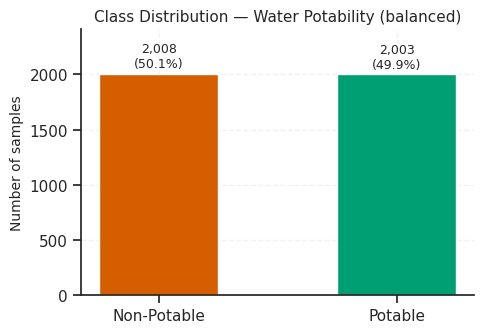

In [4]:
# Class distribution bar
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(CLASS_NAMES, counts.values, color=[CB[3], CB[2]], edgecolor="white", width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30, f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of samples")
ax.set_title("Class Distribution — Water Potability (balanced)")
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

### Train / Test Split — 80 / 20 stratified

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,}  samples (held-out — never used in CV or GridSearch)")

Training set : 3,208 samples
Test set     : 803  samples (held-out — never used in CV or GridSearch)


---
## 2 — Baseline — 5 Classifiers Accuracy Comparison
Classes are balanced (50/50); `class_weight='balanced'` kept for robustness.  
Three metrics: **Accuracy**, **F1-macro** (primary), **AUC-ROC**.

In [6]:
classifiers = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",
                                               random_state=RANDOM_STATE, max_iter=500),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",
                                                   random_state=RANDOM_STATE),
    "K-Nearest Neighbors" : KNeighborsClassifier(),
    "SVM"                 : SVC(probability=True, class_weight="balanced",
                                random_state=RANDOM_STATE),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                   random_state=RANDOM_STATE),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    acc, f1, auc_val = score_model(clf, X_test, y_test)
    results[name] = {"Accuracy": acc, "F1-macro": f1, "AUC-ROC": auc_val}
    print(f"{name:<22}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_val:.4f}")

results_df = pd.DataFrame(results).T.sort_values("F1-macro", ascending=False)
print()
print(results_df.round(4).to_string())

Logistic Regression     Acc=0.7933  F1=0.7931  AUC=0.8659
Decision Tree           Acc=0.8107  F1=0.8107  AUC=0.8107


K-Nearest Neighbors     Acc=0.7285  F1=0.7259  AUC=0.7688


SVM                     Acc=0.7534  F1=0.7441  AUC=0.7995


Random Forest           Acc=0.8941  F1=0.8941  AUC=0.9186

                     Accuracy  F1-macro  AUC-ROC
Random Forest          0.8941    0.8941   0.9186
Decision Tree          0.8107    0.8107   0.8107
Logistic Regression    0.7933    0.7931   0.8659
SVM                    0.7534    0.7441   0.7995
K-Nearest Neighbors    0.7285    0.7259   0.7688


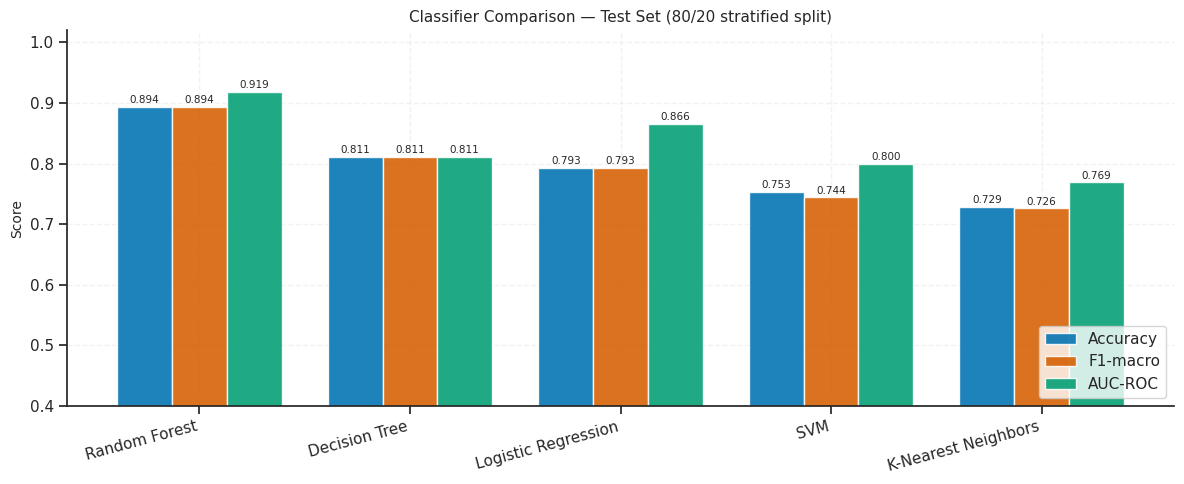

In [7]:
# Bar chart — three metrics side by side
x     = np.arange(len(results_df))
width = 0.26
metrics = ["Accuracy", "F1-macro", "AUC-ROC"]
colors  = [CB[0], CB[3], CB[2]]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1) * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.88, edgecolor="white")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.4, 1.02)
ax.set_title("Classifier Comparison — Test Set (80/20 stratified split)")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

---
## 3 — Confusion Matrix & Classification Report
Shown for the best model: **Random Forest**.

Confusion Matrix:
[[354  48]
 [ 37 364]]

              precision    recall  f1-score   support

 Non-Potable       0.91      0.88      0.89       402
     Potable       0.88      0.91      0.90       401

    accuracy                           0.89       803
   macro avg       0.89      0.89      0.89       803
weighted avg       0.89      0.89      0.89       803



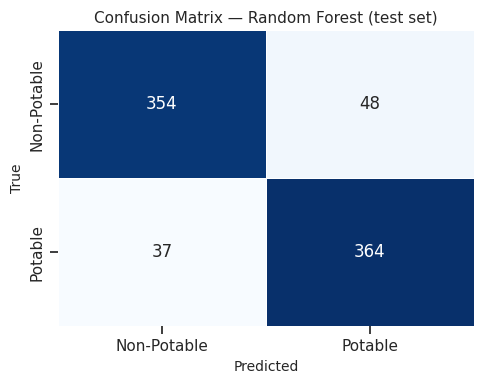

In [8]:
rf_base    = classifiers["Random Forest"]   # already fitted above
y_pred_rf  = rf_base.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Random Forest (test set)")
plt.tight_layout()
plt.show()

---
## 4 — ROC / AUC Curves

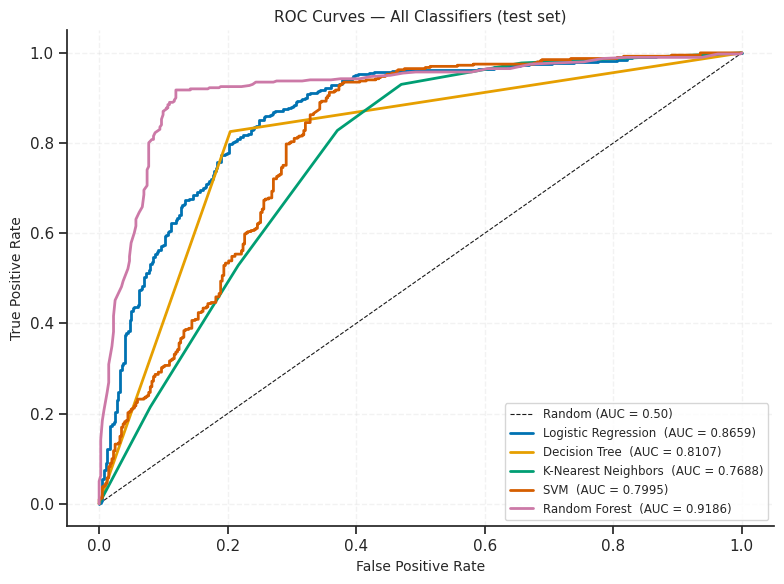

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC = 0.50)")

for (name, clf), color in zip(classifiers.items(), CB):
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {roc_val:.4f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Classifiers (test set)")
ax.legend(loc="lower right", fontsize=8.5)
sns.despine()
plt.tight_layout()
plt.show()

---
## 5 — Learning Curves (Overfitting Analysis)
Training score vs cross-validation score as training size grows.  
A large gap between the two curves indicates overfitting.

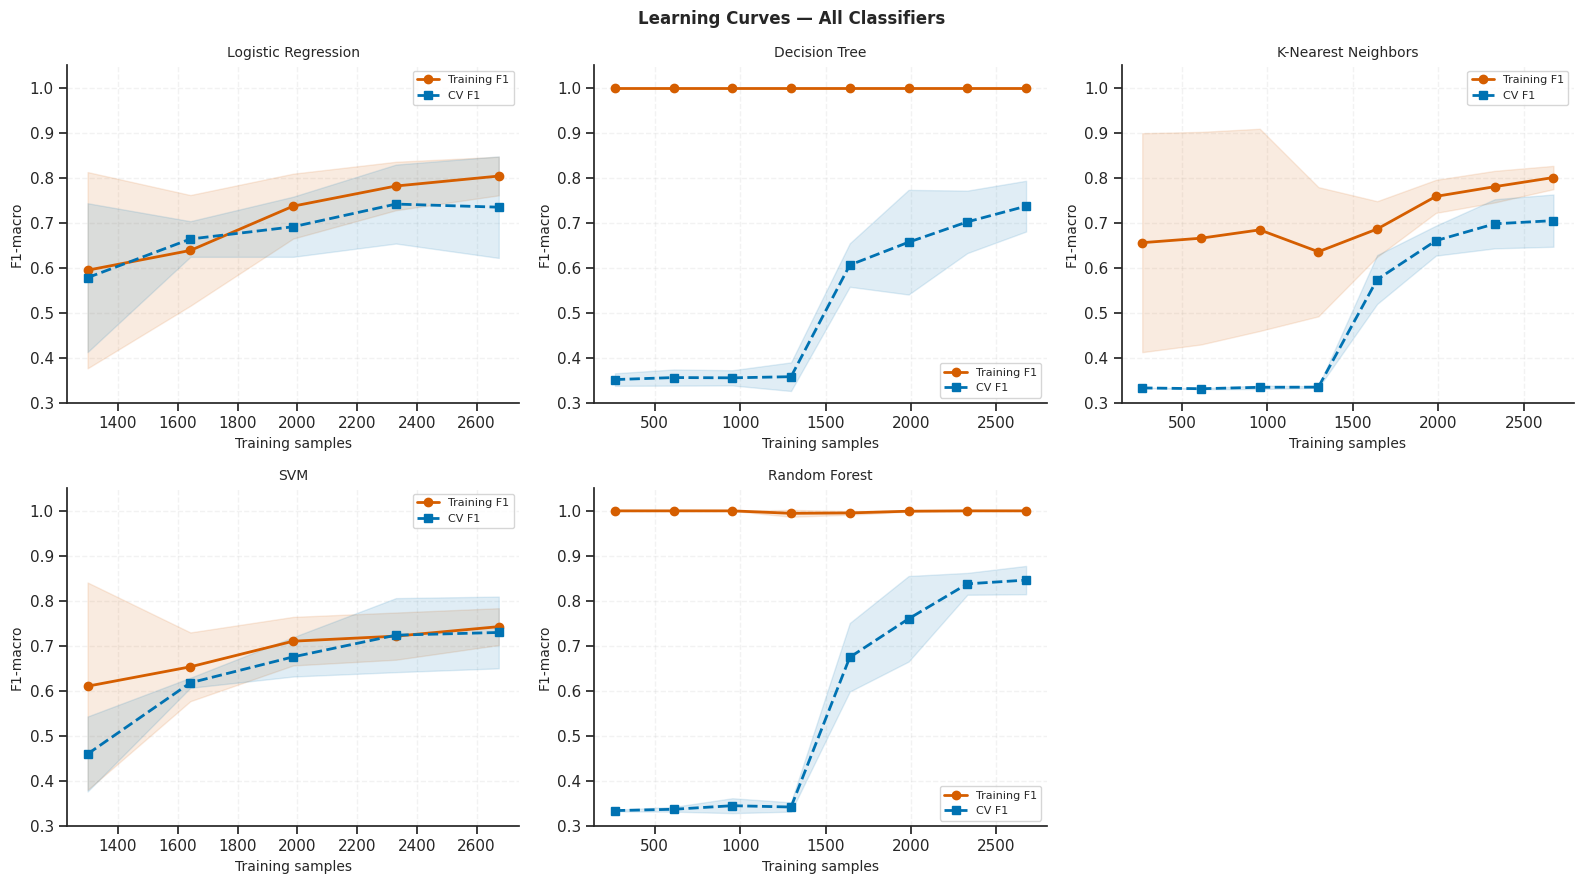

In [10]:
train_sizes_rel = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Learning Curves — All Classifiers", fontsize=12, fontweight="bold")

for ax, (name, clf_orig) in zip(axes.flatten(), classifiers.items()):
    clf_lc = clone(clf_orig)
    tr_sizes, tr_scores, cv_scores = learning_curve(
        clf_lc, X, y, cv=3, n_jobs=1,
        train_sizes=train_sizes_rel, scoring="f1_macro"
    )
    tr_mean, tr_std = tr_scores.mean(1), tr_scores.std(1)
    cv_mean, cv_std = cv_scores.mean(1), cv_scores.std(1)

    ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.12, color=CB[3])
    ax.fill_between(tr_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.12, color=CB[0])
    ax.plot(tr_sizes, tr_mean, "o-", color=CB[3], lw=2, label="Training F1")
    ax.plot(tr_sizes, cv_mean, "s--", color=CB[0], lw=2, label="CV F1")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("F1-macro")
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6 — Error vs. Tree Depth (Random Forest)
Tracks train and test error as `max_depth` increases from 1 to 30.  
The optimal depth minimises the gap between train and test error.

Optimal max_depth (min test error): 11
  Train error at best depth : 0.0577
  Test  error at best depth : 0.0984


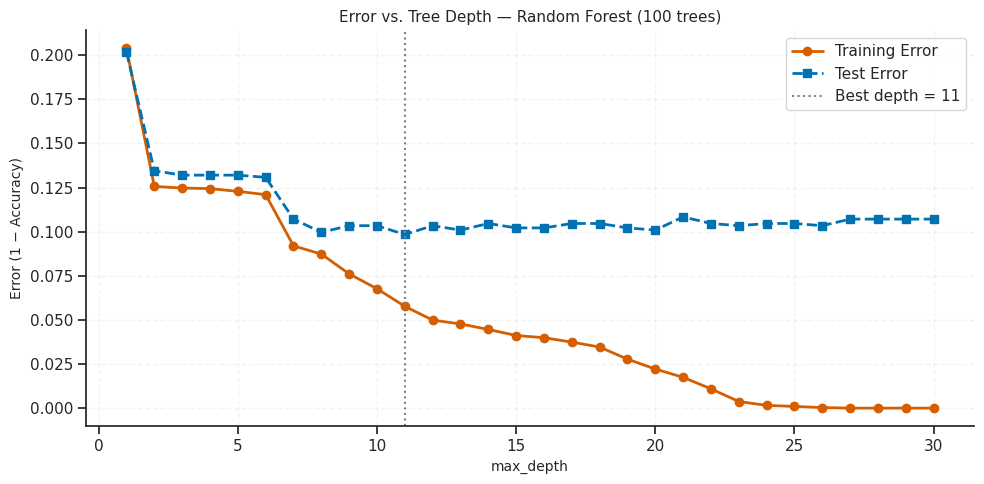

In [11]:
train_errors, test_errors = [], []
depths = range(1, 31)

for d in depths:
    m = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, m.predict(X_train)))
    test_errors.append( 1 - accuracy_score(y_test,  m.predict(X_test)))

best_depth = depths[int(np.argmin(test_errors))]
print(f"Optimal max_depth (min test error): {best_depth}")
print(f"  Train error at best depth : {train_errors[best_depth-1]:.4f}")
print(f"  Test  error at best depth : {test_errors[best_depth-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_errors, "o-", color=CB[3], lw=2, label="Training Error")
ax.plot(depths, test_errors,  "s--", color=CB[0], lw=2, label="Test Error")
ax.axvline(best_depth, color="gray", linestyle=":", lw=1.5, label=f"Best depth = {best_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Error (1 − Accuracy)")
ax.set_title("Error vs. Tree Depth — Random Forest (100 trees)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## 7 — Decision Tree Visualisation
A single Decision Tree trained on the full training set (`max_depth=4` for readability).

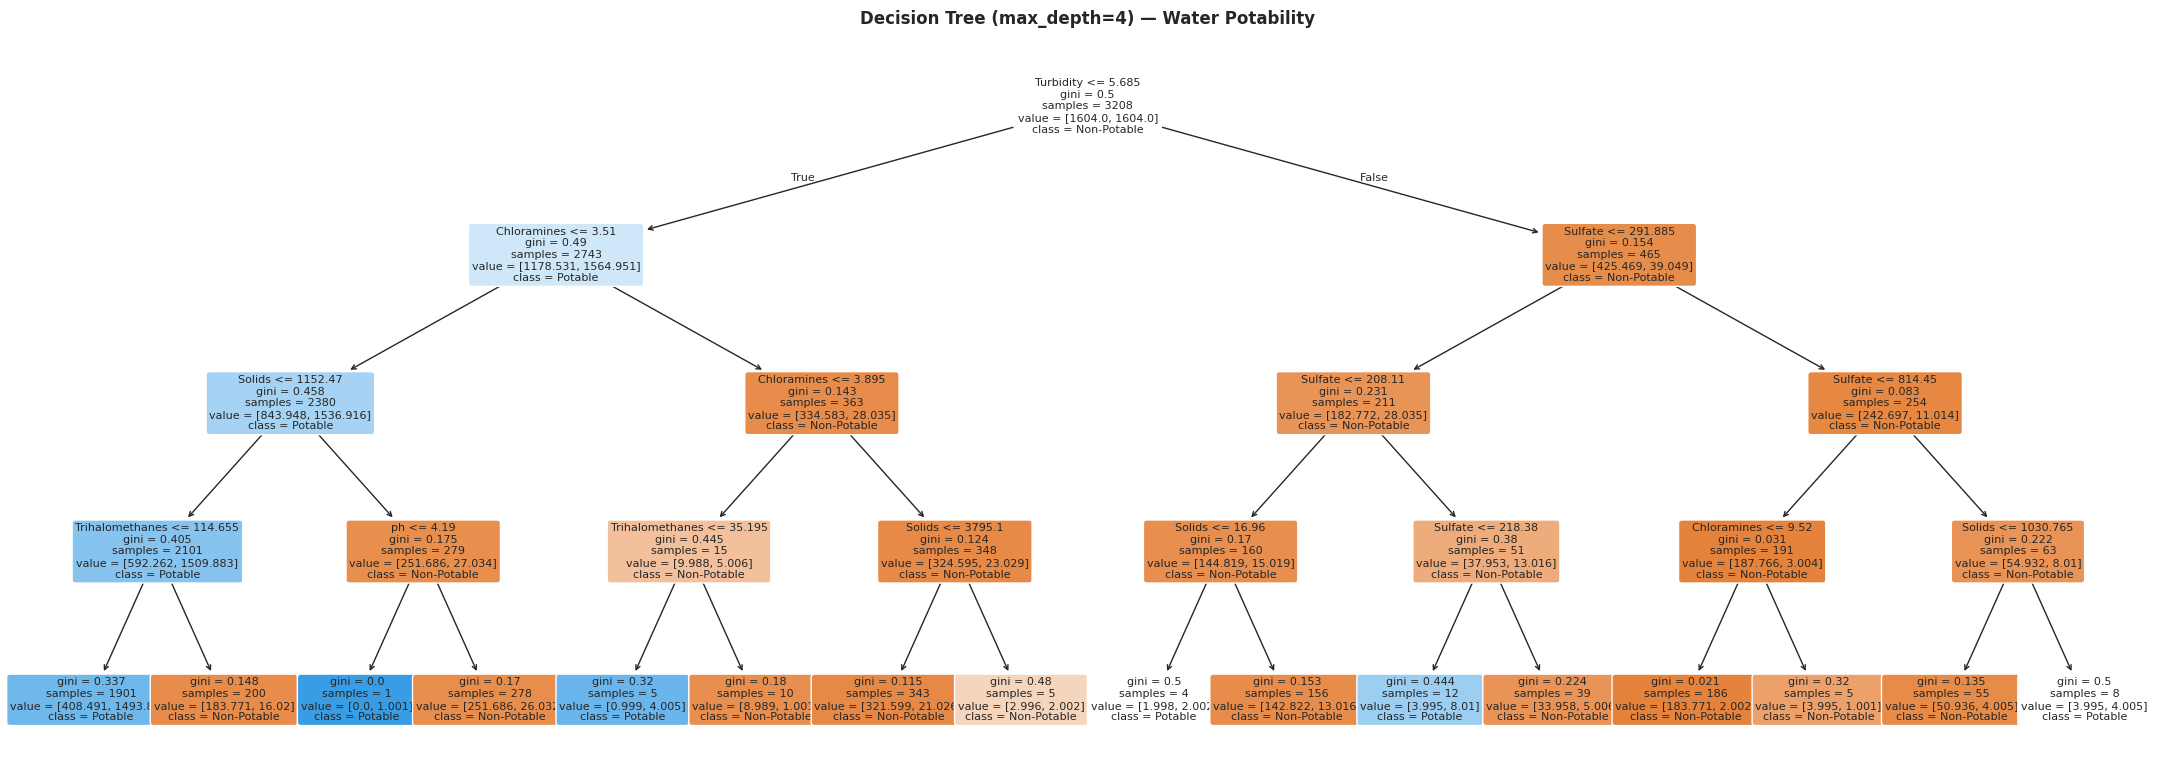

In [12]:
dt_vis = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=FEATURES,
    class_names=CLASS_NAMES,
    filled=True, rounded=True,
    fontsize=8, ax=ax,
)
ax.set_title("Decision Tree (max_depth=4) — Water Potability", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8 — Feature Importance (MDI + Permutation Importance)

Two complementary methods:
- **MDI (Mean Decrease in Impurity):** fast but biased toward high-cardinality features *(Strobl et al., 2007)*
- **Permutation Importance (PI):** accuracy drop when feature is shuffled on test set — unbiased, 30 repetitions

In [13]:
rf_fi = clone(RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE))
rf_fi.fit(X_train, y_train)
base_acc, base_f1, base_auc = score_model(rf_fi, X_test, y_test)

print(f"Baseline RF  Acc={base_acc:.4f}  F1={base_f1:.4f}  AUC={base_auc:.4f}")
print()

mdi  = pd.Series(rf_fi.feature_importances_, index=FEATURES)
perm = permutation_importance(rf_fi, X_test, y_test, n_repeats=30,
                               random_state=RANDOM_STATE, n_jobs=-1)
pi_mean = pd.Series(perm.importances_mean, index=FEATURES)
pi_std  = pd.Series(perm.importances_std,  index=FEATURES)

imp_df = pd.DataFrame({
    "MDI (Gini)" : mdi,
    "MDI Rank"   : mdi.rank(ascending=False).astype(int),
    "PI Mean"    : pi_mean,
    "PI Std"     : pi_std,
    "PI Rank"    : pi_mean.rank(ascending=False).astype(int),
}).sort_values("MDI (Gini)", ascending=False)

print("Feature Importance Table")
print(imp_df.round(4).to_string())

Baseline RF  Acc=0.8941  F1=0.8941  AUC=0.9186



Feature Importance Table
                 MDI (Gini)  MDI Rank  PI Mean  PI Std  PI Rank
Solids               0.1764         1   0.0778  0.0092        4
Chloramines          0.1750         2   0.0771  0.0070        5
Trihalomethanes      0.1728         3   0.0717  0.0084        6
Turbidity            0.1686         4   0.0833  0.0090        1
Sulfate              0.1603         5   0.0781  0.0072        3
ph                   0.1468         6   0.0783  0.0084        2


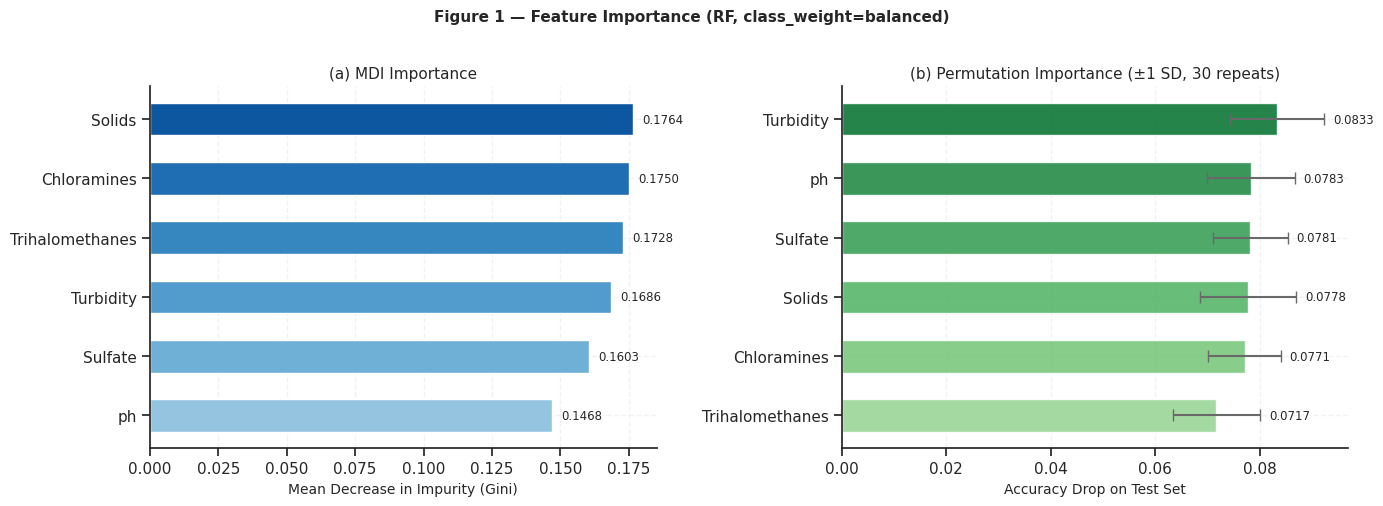

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1 — Feature Importance (RF, class_weight=balanced)",
             fontsize=11, fontweight="bold", y=1.01)
n_feat = len(FEATURES)

order_mdi = mdi.sort_values(ascending=True)
bars_a = axes[0].barh(order_mdi.index, order_mdi.values,
                      color=plt.cm.Blues(np.linspace(0.4, 0.85, n_feat)),
                      edgecolor="white", height=0.55)
axes[0].set_xlabel("Mean Decrease in Impurity (Gini)")
axes[0].set_title("(a) MDI Importance")
for b, v in zip(bars_a, order_mdi.values):
    axes[0].text(v + order_mdi.max()*0.02, b.get_y()+b.get_height()/2,
                 f"{v:.4f}", va="center", fontsize=8.5)

order_pi = pi_mean.sort_values(ascending=True)
axes[1].barh(order_pi.index, pi_mean[order_pi.index],
             xerr=pi_std[order_pi.index],
             color=plt.cm.Greens(np.linspace(0.4, 0.85, n_feat)),
             capsize=4, ecolor="dimgray", edgecolor="white", height=0.55, alpha=0.88)
axes[1].set_xlabel("Accuracy Drop on Test Set")
axes[1].set_title("(b) Permutation Importance (±1 SD, 30 repeats)")
for feat in order_pi.index:
    v = pi_mean[feat]
    axes[1].text(v + pi_std[feat] + pi_mean.abs().max()*0.02,
                 list(order_pi.index).index(feat),
                 f"{v:.4f}", va="center", fontsize=8.5)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

---
## 9 — Feature Ablation Study

Three experiments — same RF template (100 trees, balanced):

- **(a) Leave-One-Out (LOO):** remove each feature one at a time
- **(b) Forward Selection:** add features in MDI rank order
- **(c) Exhaustive Subsets:** all 2⁶ − 1 = 63 non-empty subsets

In [15]:
RF_TPL     = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)
feat_order = mdi.sort_values(ascending=False).index.tolist()
n_feat     = len(FEATURES)

# (a) Leave-One-Out
loo = []
for feat in FEATURES:
    rem = [f for f in FEATURES if f != feat]
    acc, f1, auc_v = fit_score(RF_TPL, X_train[rem], y_train, X_test[rem], y_test)
    loo.append({"Removed": feat, "F1": f1, "delta_F1": round(f1 - base_f1, 4),
                "Accuracy": acc, "AUC": auc_v})
loo_df = pd.DataFrame(loo).sort_values("delta_F1", ascending=False).set_index("Removed")
print("(a) Leave-One-Out (delta_F1 negatif = feature utile)")
print(loo_df.round(4).to_string())

# (b) Forward Selection
fwd = []
for k in range(1, n_feat + 1):
    sub = feat_order[:k]
    acc, f1, auc_v = fit_score(RF_TPL, X_train[sub], y_train, X_test[sub], y_test)
    fwd.append({"N": k, "Features": " + ".join(sub), "F1": f1, "Acc": acc, "AUC": auc_v})
fwd_df = pd.DataFrame(fwd)
print("\n(b) Forward Feature Selection")
print(fwd_df.to_string(index=False))

# (c) Exhaustive subsets (63 combos for 6 features)
subs = []
total = sum(len(list(combinations(FEATURES, r))) for r in range(1, n_feat+1))
print(f"\n(c) Exhaustive subsets ({total} combos total) ...")
for r in range(1, n_feat + 1):
    for combo in combinations(FEATURES, r):
        c = list(combo)
        acc, f1, auc_v = fit_score(RF_TPL, X_train[c], y_train, X_test[c], y_test)
        subs.append({"Subset": " + ".join(c), "Size": r, "F1": f1, "Acc": acc, "AUC": auc_v})
sub_df = pd.DataFrame(subs).sort_values(["Size", "F1"], ascending=[True, False])
best_sub = sub_df.loc[sub_df["F1"].idxmax()]
print(f"Optimal subset: {best_sub['Subset']}  =>  F1={best_sub['F1']:.4f}")
print(sub_df.sort_values("F1", ascending=False).head(10).round(4).to_string(index=False))

(a) Leave-One-Out (delta_F1 negatif = feature utile)
                     F1  delta_F1  Accuracy     AUC
Removed                                            
Trihalomethanes  0.8765   -0.0176    0.8767  0.8966
Turbidity        0.8714   -0.0227    0.8717  0.8838
Solids           0.8690   -0.0252    0.8692  0.8902
Chloramines      0.8678   -0.0263    0.8680  0.8810
Sulfate          0.8640   -0.0301    0.8643  0.8816
ph               0.8615   -0.0326    0.8618  0.8900



(b) Forward Feature Selection
 N                                                          Features       F1      Acc      AUC
 1                                                            Solids 0.531435 0.531756 0.571320
 2                                              Solids + Chloramines 0.621726 0.622665 0.678555
 3                            Solids + Chloramines + Trihalomethanes 0.753279 0.755915 0.800096
 4                Solids + Chloramines + Trihalomethanes + Turbidity 0.813603 0.814446 0.838985
 5      Solids + Chloramines + Trihalomethanes + Turbidity + Sulfate 0.861548 0.861768 0.881010
 6 Solids + Chloramines + Trihalomethanes + Turbidity + Sulfate + ph 0.896622 0.896638 0.916685

(c) Exhaustive subsets (63 combos total) ...


Optimal subset: ph + Solids + Chloramines + Sulfate + Trihalomethanes + Turbidity  =>  F1=0.8954
                                                           Subset  Size     F1    Acc    AUC
ph + Solids + Chloramines + Sulfate + Trihalomethanes + Turbidity     6 0.8954 0.8954 0.9171
                  ph + Solids + Chloramines + Sulfate + Turbidity     5 0.8765 0.8767 0.8966
            ph + Solids + Chloramines + Sulfate + Trihalomethanes     5 0.8714 0.8717 0.8838
         ph + Chloramines + Sulfate + Trihalomethanes + Turbidity     5 0.8690 0.8692 0.8902
              ph + Solids + Sulfate + Trihalomethanes + Turbidity     5 0.8678 0.8680 0.8810
          ph + Solids + Chloramines + Trihalomethanes + Turbidity     5 0.8640 0.8643 0.8816
     Solids + Chloramines + Sulfate + Trihalomethanes + Turbidity     5 0.8615 0.8618 0.8900
                           ph + Chloramines + Sulfate + Turbidity     4 0.8309 0.8319 0.8557
                      ph + Solids + Chloramines + Trihalomethanes 

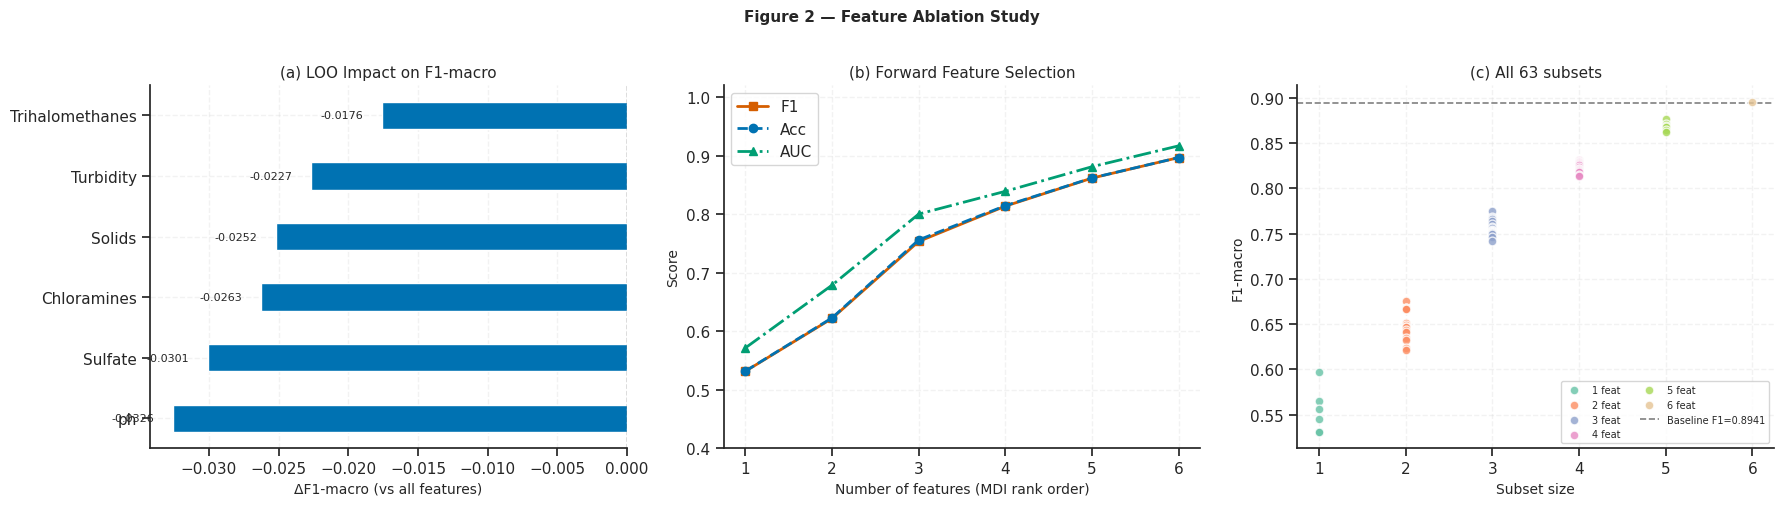

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 2 — Feature Ablation Study", fontsize=11, fontweight="bold", y=1.01)

# (a) LOO
delta_f1 = loo_df["delta_F1"].sort_values(ascending=True)
colors_loo = [CB[2] if v >= 0 else CB[0] for v in delta_f1]
axes[0].barh(delta_f1.index, delta_f1.values, color=colors_loo, edgecolor="white", height=0.45)
axes[0].axvline(0, color="black", lw=0.9, linestyle="--")
axes[0].set_xlabel("ΔF1-macro (vs all features)")
axes[0].set_title("(a) LOO Impact on F1-macro")
for i, v in enumerate(delta_f1.values):
    axes[0].text(v + (delta_f1.abs().max()*0.04 if v >= 0 else -delta_f1.abs().max()*0.04),
                 i, f"{v:+.4f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)

# (b) Forward selection
for metric, color, ls, m in zip(["F1","Acc","AUC"], [CB[3],CB[0],CB[2]],
                                  ["-","--","-."], ["s","o","^"]):
    axes[1].plot(fwd_df["N"], fwd_df[metric], m+ls, color=color, lw=2, label=metric)
axes[1].set_xlabel("Number of features (MDI rank order)")
axes[1].set_ylabel("Score")
axes[1].set_title("(b) Forward Feature Selection")
axes[1].set_xticks(fwd_df["N"])
axes[1].legend()
axes[1].set_ylim(0.4, 1.02)

# (c) Scatter by subset size
sizes = sorted(sub_df["Size"].unique())
cmap_c = plt.cm.Set2(np.linspace(0, 0.75, len(sizes)))
for idx_s, size_k in enumerate(sizes):
    sub = sub_df[sub_df["Size"] == size_k]
    axes[2].scatter([size_k]*len(sub), sub["F1"],
                    color=cmap_c[idx_s], s=40, alpha=0.8,
                    label=f"{size_k} feat", zorder=3, edgecolors="white")
axes[2].axhline(base_f1, color="gray", linestyle="--", lw=1.2,
                label=f"Baseline F1={base_f1:.4f}")
axes[2].set_xlabel("Subset size")
axes[2].set_ylabel("F1-macro")
axes[2].set_title("(c) All 63 subsets")
axes[2].legend(fontsize=7, ncol=2)
axes[2].set_xticks(sizes)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

---
## 10 — Hyperparameter Optimisation — GridSearchCV
**18 combinations × 5-fold CV = 90 fits**. Scoring: F1-macro. X_test never touched.  
Grid: `n_estimators` × `max_depth` × `max_features`.

In [17]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth"   : [None, 10, 20],
    "max_features": ["sqrt", "log2"],
}
# 3 × 3 × 2 = 18 combos × 5 folds = 90 fits

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid, cv=cv_inner, scoring="f1_macro",
    n_jobs=-1, verbose=1, return_train_score=True, refit=True,
)

print("Running GridSearchCV (18 × 5 = 90 fits) ...")
gs.fit(X_train, y_train)

best_params = gs.best_params_
best_model  = gs.best_estimator_
opt_acc, opt_f1, opt_auc = score_model(best_model, X_test, y_test)

print(f"\nBest params  : {best_params}")
print(f"Best CV F1   : {gs.best_score_:.4f}")
print(f"\n{'Metric':<12} {'Default RF':>12} {'Optimised RF':>14}")
print(f"{'-'*40}")
print(f"{'Accuracy':<12} {base_acc:>12.4f} {opt_acc:>14.4f}")
print(f"{'F1-macro':<12} {base_f1:>12.4f} {opt_f1:>14.4f}")
print(f"{'AUC-ROC':<12} {base_auc:>12.4f} {opt_auc:>14.4f}")

Running GridSearchCV (18 × 5 = 90 fits) ...
Fitting 5 folds for each of 18 candidates, totalling 90 fits



Best params  : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV F1   : 0.8996

Metric         Default RF   Optimised RF
----------------------------------------
Accuracy           0.8941         0.8991
F1-macro           0.8941         0.8991
AUC-ROC            0.9186         0.9172


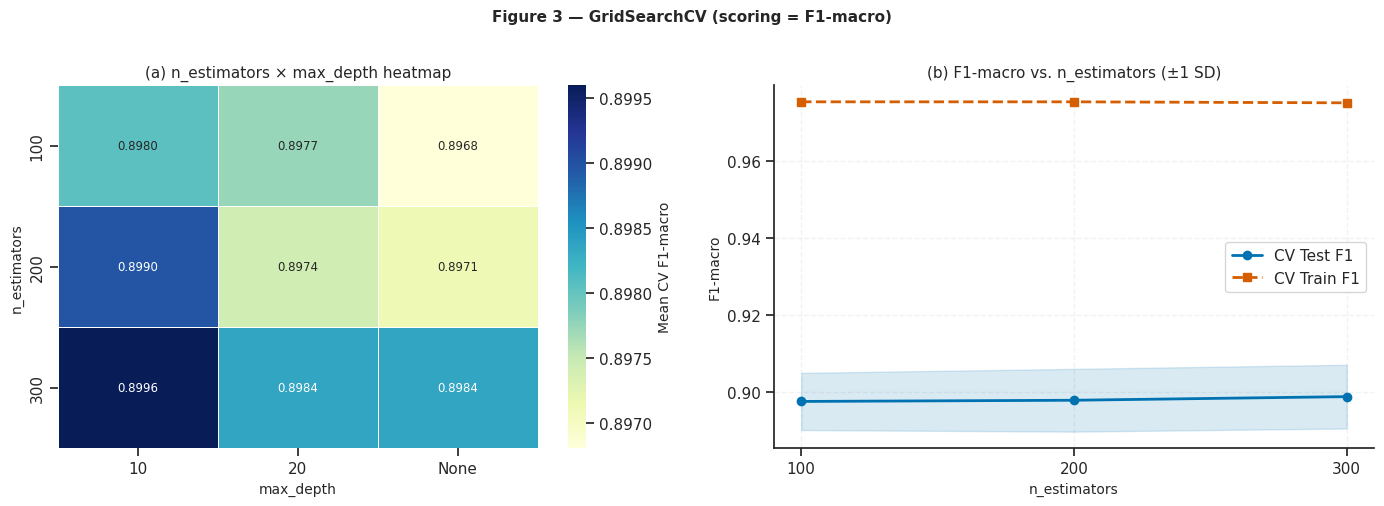

In [18]:
cv_res = pd.DataFrame(gs.cv_results_)
cv_res["depth_str"] = cv_res["param_max_depth"].fillna("None").astype(str)
hm = (cv_res.groupby(["param_n_estimators", "depth_str"])["mean_test_score"]
           .mean().unstack())
col_order = [c for c in ["5", "10", "20", "None"] if c in hm.columns]
hm = hm[col_order]

ne = (cv_res.groupby("param_n_estimators")
           .agg(mt=("mean_test_score", "mean"), st=("std_test_score", "mean"),
                mtr=("mean_train_score", "mean"))
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3 — GridSearchCV (scoring = F1-macro)",
             fontsize=11, fontweight="bold", y=1.01)

sns.heatmap(hm, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0],
            linewidths=0.4, linecolor="white", annot_kws={"size": 8.5},
            cbar_kws={"label": "Mean CV F1-macro"})
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("n_estimators")
axes[0].set_title("(a) n_estimators × max_depth heatmap")

axes[1].plot(ne["param_n_estimators"], ne["mt"], "o-", color=CB[0], lw=2, label="CV Test F1")
axes[1].fill_between(ne["param_n_estimators"],
                     ne["mt"] - ne["st"], ne["mt"] + ne["st"], alpha=0.15, color=CB[0])
axes[1].plot(ne["param_n_estimators"], ne["mtr"], "s--", color=CB[3], lw=2, label="CV Train F1")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("F1-macro")
axes[1].set_title("(b) F1-macro vs. n_estimators (±1 SD)")
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.FixedLocator(ne["param_n_estimators"].tolist()))
sns.despine(ax=axes[1])
fig.tight_layout()
plt.show()

---
## 11 — Stratified 10-Fold Cross-Validation
CV performed **exclusively on X_train**. X_test remains independent.  
95% CI uses t-distribution: SE = std / √10, df = 9.

In [19]:
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_clf = {
    "RF Optimised"       : clone(best_model),
    "RF Default"         : RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                   random_state=RANDOM_STATE),
    "Decision Tree"      : DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "KNN"                : KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(class_weight="balanced",
                                              random_state=RANDOM_STATE, max_iter=500),
    "SVM"                : SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
}

cv_records, cv_f1_all = {}, {}
print(f"10-fold CV on X_train ({len(X_train):,} samples)\n")

for name, clf in cv_clf.items():
    s_acc = cross_val_score(clf, X_train, y_train, cv=cv_outer, scoring="accuracy", n_jobs=1)
    s_f1  = cross_val_score(clf, X_train, y_train, cv=cv_outer, scoring="f1_macro",  n_jobs=1)
    s_auc = cross_val_score(clf, X_train, y_train, cv=cv_outer, scoring="roc_auc",   n_jobs=1)
    m, s, lo, hi = cv_ci(s_f1)
    cv_f1_all[name] = s_f1
    cv_records[name] = {"Acc Mean": s_acc.mean(), "F1 Mean": m, "F1 Std": s,
                        "AUC Mean": s_auc.mean(), "CI Lo": lo, "CI Hi": hi}
    print(f"  {name:<22}  Acc={s_acc.mean():.4f}  F1={m:.4f}±{s:.4f}  AUC={s_auc.mean():.4f}")

cv_df = (pd.DataFrame(cv_records).T.astype(float)
           .sort_values("F1 Mean", ascending=False).reset_index()
           .rename(columns={"index": "Model"}))
cv_df.index += 1
print("\n", cv_df[["Model","Acc Mean","F1 Mean","F1 Std","AUC Mean","CI Lo","CI Hi"]].round(4).to_string())

10-fold CV on X_train (3,208 samples)



  RF Optimised            Acc=0.8990  F1=0.8990±0.0140  AUC=0.9099


  RF Default              Acc=0.8974  F1=0.8974±0.0111  AUC=0.9080


  Decision Tree           Acc=0.8089  F1=0.8087±0.0119  AUC=0.8089


  KNN                     Acc=0.7248  F1=0.7228±0.0153  AUC=0.7673


  Logistic Regression     Acc=0.8036  F1=0.8028±0.0227  AUC=0.8575


  SVM                     Acc=0.7544  F1=0.7465±0.0157  AUC=0.7876

                  Model  Acc Mean  F1 Mean  F1 Std  AUC Mean   CI Lo   CI Hi
1         RF Optimised    0.8990   0.8990  0.0140    0.9099  0.8890  0.9090
2           RF Default    0.8974   0.8974  0.0111    0.9080  0.8895  0.9053
3        Decision Tree    0.8089   0.8087  0.0119    0.8089  0.8001  0.8172
4  Logistic Regression    0.8036   0.8028  0.0227    0.8575  0.7866  0.8190
5                  SVM    0.7544   0.7465  0.0157    0.7876  0.7353  0.7577
6                  KNN    0.7248   0.7228  0.0153    0.7673  0.7118  0.7337


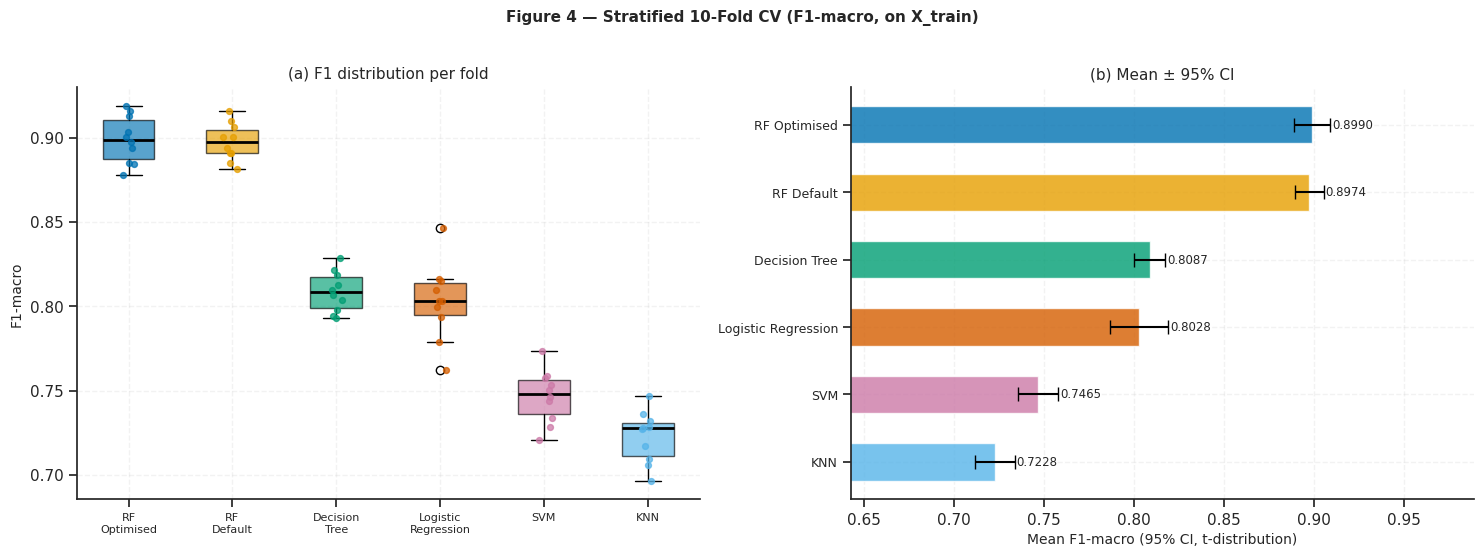

In [20]:
names_ord = cv_df["Model"].tolist()
data_f1   = [cv_f1_all[n] for n in names_ord]
palette   = CB[:len(names_ord)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("Figure 4 — Stratified 10-Fold CV (F1-macro, on X_train)",
             fontsize=11, fontweight="bold", y=1.01)

# (a) Box + jitter
bp = axes[0].boxplot(data_f1, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color); patch.set_alpha(0.65)
rng = np.random.default_rng(0)
for j, d in enumerate(data_f1):
    jitter = rng.normal(0, 0.04, size=len(d))
    axes[0].scatter(np.full(len(d), j+1)+jitter, d,
                    color=palette[j], s=18, alpha=0.75, zorder=4)
axes[0].set_xticks(range(1, len(names_ord)+1))
axes[0].set_xticklabels([n.replace(" ", chr(10)) for n in names_ord], fontsize=8)
axes[0].set_ylabel("F1-macro")
axes[0].set_title("(a) F1 distribution per fold")

# (b) Mean ± 95% CI
y_pos  = np.arange(len(names_ord))
f1m    = cv_df["F1 Mean"].values.astype(float)
lo_err = f1m - cv_df["CI Lo"].values.astype(float)
hi_err = cv_df["CI Hi"].values.astype(float) - f1m
axes[1].barh(y_pos, f1m, xerr=[lo_err, hi_err],
             color=palette, alpha=0.80, capsize=5, ecolor="black", height=0.55)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(names_ord, fontsize=9)
axes[1].set_xlabel("Mean F1-macro (95% CI, t-distribution)")
axes[1].set_title("(b) Mean ± 95% CI")
axes[1].invert_yaxis()
for i, (m, l, h) in enumerate(zip(f1m, lo_err, hi_err)):
    axes[1].text(m+h+0.001, i, f"{m:.4f}", va="center", fontsize=8.5)
axes[1].set_xlim(max(0, f1m.min()-0.08), f1m.max()+0.09)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

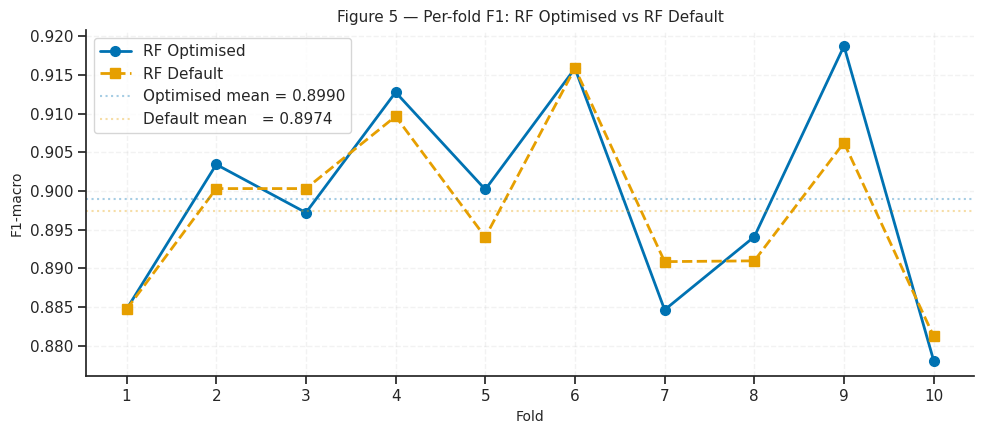

In [21]:
# Per-fold evolution — RF Optimised vs RF Default
fig, ax = plt.subplots(figsize=(10, 4.5))
folds = range(1, 11)
ax.plot(folds, cv_f1_all["RF Optimised"], "o-", color=CB[0], lw=2, ms=7, label="RF Optimised")
ax.plot(folds, cv_f1_all["RF Default"],   "s--", color=CB[1], lw=2, ms=7, label="RF Default")
ax.axhline(cv_f1_all["RF Optimised"].mean(), color=CB[0], alpha=0.35, linestyle=":",
           label=f"Optimised mean = {cv_f1_all['RF Optimised'].mean():.4f}")
ax.axhline(cv_f1_all["RF Default"].mean(),   color=CB[1], alpha=0.35, linestyle=":",
           label=f"Default mean   = {cv_f1_all['RF Default'].mean():.4f}")
ax.set_xlabel("Fold")
ax.set_ylabel("F1-macro")
ax.set_title("Figure 5 — Per-fold F1: RF Optimised vs RF Default")
ax.set_xticks(list(folds))
ax.legend()
sns.despine()
fig.tight_layout()
plt.show()

---
## 12 — Global Summary

In [22]:
sep = "=" * 70
print(f"\n{sep}")
print("COMPLETE ANALYSIS SUMMARY — water_potability.csv")
print(sep)

print(f"\nDataset : water_potability.csv — {len(df):,} samples, {len(FEATURES)} features, balanced")
print(f"Features: {FEATURES}")
print(f"Split   : 80/20 stratified — Train={len(X_train):,} / Test={len(X_test):,}")

print(f"\n{'Evaluation':<48} {'Accuracy':>9} {'F1-macro':>9} {'AUC-ROC':>9}")
print("-" * 70)
print(f"{'RF Default   — test set':<48} {base_acc:>9.4f} {base_f1:>9.4f} {base_auc:>9.4f}")
print(f"{'RF Optimised — test set':<48} {opt_acc:>9.4f} {opt_f1:>9.4f} {opt_auc:>9.4f}")
for nm in ["RF Optimised", "RF Default"]:
    row = cv_df[cv_df["Model"] == nm].iloc[0]
    print(f"{'10-Fold CV — '+nm:<48} {row['Acc Mean']:>9.4f} {row['F1 Mean']:>9.4f} {row['AUC Mean']:>9.4f}")
print("-" * 70)

print(f"\nBest hyperparameters (GridSearchCV, F1-macro):")
for k, v in best_params.items():
    print(f"  {k:<26} = {v}")

print(f"\nFeature importance (MDI rank):")
for feat, row in imp_df.iterrows():
    print(f"  {feat:<18} MDI={row['MDI (Gini)']:.4f}  PI={row['PI Mean']:+.4f}")

print(f"\nOptimal feature subset (exhaustive search, all 63 subsets):")
print(f"  {best_sub['Subset']}  =>  F1 = {best_sub['F1']:.4f}")

print(f"\n10-Fold CV ranking (by F1-macro):")
for _, row in cv_df.iterrows():
    print(f"  {int(row.name)}. {row['Model']:<22}  F1={row['F1 Mean']:.4f}±{row['F1 Std']:.4f}  "
          f"AUC={row['AUC Mean']:.4f}  95%CI=[{row['CI Lo']:.4f},{row['CI Hi']:.4f}]")


COMPLETE ANALYSIS SUMMARY — water_potability.csv

Dataset : water_potability.csv — 4,011 samples, 6 features, balanced
Features: ['ph', 'Solids', 'Chloramines', 'Sulfate', 'Trihalomethanes', 'Turbidity']
Split   : 80/20 stratified — Train=3,208 / Test=803

Evaluation                                        Accuracy  F1-macro   AUC-ROC
----------------------------------------------------------------------
RF Default   — test set                             0.8941    0.8941    0.9186
RF Optimised — test set                             0.8991    0.8991    0.9172
10-Fold CV — RF Optimised                           0.8990    0.8990    0.9099
10-Fold CV — RF Default                             0.8974    0.8974    0.9080
----------------------------------------------------------------------

Best hyperparameters (GridSearchCV, F1-macro):
  max_depth                  = 10
  max_features               = sqrt
  n_estimators               = 300

Feature importance (MDI rank):
  Solids            